<a href="https://colab.research.google.com/github/Adamphoenix003/GNN-LinkPrediction/blob/main/SFDDGNN_Colab_Fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SFDDGNN — Fixed Install for Google Colab (T4 / any GPU)

**Problem:** The generic `pip install torch-scatter torch-sparse` builds do not match your
exact PyTorch + CUDA version and produce `_version_cuda.so` load errors.

**Fix:** This notebook auto-detects your versions and installs the exact matching wheels.

**Order:**
1. Run **Step 1** (auto-detects versions + installs). Then **Runtime → Restart session**.
2. Run **Step 2** (verify — should print OK with no warnings).
3. Continue with Steps 3–9 (all model code, identical to before).


## Step 1 — Auto-detected Install

Runs `torch.__version__` and `torch.version.cuda` to build the correct PyG wheel URL.
> After this cell: **Runtime → Restart session**

In [1]:
# ── Detect exact PyTorch + CUDA version and install matching wheels ──
import subprocess, sys, torch

torch_ver = torch.__version__.split('+')[0]          # e.g. '2.3.0'
cuda_ver  = torch.version.cuda.replace('.', '')      # e.g. '121'
print(f'PyTorch {torch_ver}  |  CUDA {cuda_ver}')

# Uninstall any mismatched builds first
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
                'torch-scatter', 'torch-sparse', 'torch-geometric'], check=False)

# Install pyg-lib + scatter + sparse matching your exact versions
url = f'https://data.pyg.org/whl/torch-{torch_ver}+cu{cuda_ver}.html'
print(f'Installing from: {url}')
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch-scatter', 'torch-sparse', 'torch-geometric',
    '-f', url
], check=True)

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers', 'scikit-learn', 'matplotlib'
], check=True)

print('\nDone! Restart the runtime now: Runtime -> Restart session')


PyTorch 2.10.0  |  CUDA 128
Installing from: https://data.pyg.org/whl/torch-2.10.0+cu128.html

Done! Restart the runtime now: Runtime -> Restart session


## Step 2 — Verify (run after restart)

In [2]:
# ── Verify everything loads cleanly (no UserWarning) ──
import warnings
warnings.filterwarnings('error', category=UserWarning)
try:
    import torch_geometric
    print(f'torch-geometric {torch_geometric.__version__}  OK')
    from torch_geometric.nn import SAGEConv
    from torch_geometric.utils import to_undirected, negative_sampling
    print('SAGEConv, to_undirected, negative_sampling  OK')
except UserWarning as e:
    print(f'Still a warning: {e}')
    print('Try: Runtime -> Restart session, then re-run this cell')
finally:
    warnings.resetwarnings()

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


torch-geometric 2.7.0  OK
SAGEConv, to_undirected, negative_sampling  OK
Device: cuda
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 3 — Imports

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import to_undirected, negative_sampling
import torch_geometric.transforms as T

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 4 — Define Model Components
### 4a. ELSE Encoder

In [4]:
class DeepWalkEmbedding(nn.Module):
    def __init__(self, num_nodes, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
    def forward(self, node_ids):
        return self.embedding(node_ids)

class Node2VecEmbedding(nn.Module):
    def __init__(self, num_nodes, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
    def forward(self, node_ids):
        return self.embedding(node_ids)

class MatrixFactorizationEmbedding(nn.Module):
    def __init__(self, num_nodes, embedding_dim):
        super().__init__()
        self.U = nn.Embedding(num_nodes, embedding_dim)
        self.V = nn.Embedding(num_nodes, embedding_dim)
    def forward(self, node_ids):
        return self.U(node_ids) + self.V(node_ids)

class EnsembleLearningStructureEncoder(nn.Module):
    def __init__(self, num_nodes, basis_dim=64, output_dim=256):
        super().__init__()
        self.deepwalk = DeepWalkEmbedding(num_nodes, basis_dim)
        self.node2vec = Node2VecEmbedding(num_nodes, basis_dim)
        self.mf       = MatrixFactorizationEmbedding(num_nodes, basis_dim)
        self.mlp = nn.Sequential(
            nn.Linear(basis_dim * 3, output_dim),
            nn.ReLU(),
            nn.Linear(output_dim, output_dim),
        )
    def forward(self, node_ids):
        h = torch.cat([
            self.deepwalk(node_ids),
            self.node2vec(node_ids),
            self.mf(node_ids),
        ], dim=-1)
        return self.mlp(h)

print('ELSE defined')


ELSE defined


### 4b. GraphSAGE Structure Encoder

In [5]:
class GraphSAGEStructureEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=256, out_dim=128, dropout=0.5):
        super().__init__()
        self.conv1        = SAGEConv(in_dim, hidden_dim)
        self.conv2        = SAGEConv(hidden_dim, out_dim)
        self.dropout      = nn.Dropout(dropout)
        self.edge_update1 = nn.Linear(in_dim * 2, hidden_dim)
        self.edge_update2 = nn.Linear(hidden_dim + out_dim * 2, out_dim)
        self.readout      = nn.Linear(out_dim, 1)

    def forward(self, x, edge_index, src, dst):
        h_edge0 = F.relu(self.edge_update1(
            torch.cat([x[src], x[dst]], dim=-1)))
        h1 = F.relu(self.conv1(x, edge_index))
        h1 = self.dropout(h1)
        h2 = self.conv2(h1, edge_index)
        h_edge1 = F.relu(self.edge_update2(
            torch.cat([h_edge0, h2[src], h2[dst]], dim=-1)))
        logits = self.readout(h_edge1).squeeze(-1)
        return h2, logits

    @staticmethod
    def structure_loss(logits, labels):
        return F.binary_cross_entropy_with_logits(logits, labels.float())

print('GraphSAGE Structure Encoder defined')


GraphSAGE Structure Encoder defined


### 4c. Feature Encoder

In [6]:
class FeatureEncoder(nn.Module):
    def __init__(self, input_dim=768, output_dim=128, dropout=0.1, lambda_reg=1e-5):
        super().__init__()
        self.lambda_reg = lambda_reg
        self.projector = nn.Sequential(
            nn.Linear(input_dim, output_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim * 2, output_dim),
        )
    def forward(self, x_feat):
        return self.projector(x_feat)

    def contrastive_loss(self, h_i, h_j, h_k):
        def cos(a, b):
            return F.cosine_similarity(a, b, dim=-1)
        sim_ij = cos(h_i, h_j)
        sim_ik = cos(h_i, h_k)
        sim_kj = cos(h_k, h_j)
        pos_loss = -torch.log(
            torch.exp(sim_ij) / (torch.exp(sim_ij) + torch.exp(sim_ik) + 1e-8)
        ).mean()
        neg_loss = torch.log(
            torch.exp(sim_kj) / (torch.exp(sim_ij) + torch.exp(sim_kj) + 1e-8)
        ).mean()
        l2 = self.lambda_reg * sum(
            p.norm(2)**2 for p in self.projector.parameters())
        return pos_loss + neg_loss + l2

print('Feature Encoder defined')


Feature Encoder defined


### 4d. Graph Embedding Module

In [7]:
class GraphEmbeddingModule(nn.Module):
    def __init__(self, node_dim, graph_dim=128):
        super().__init__()
        self.node_proj  = nn.Linear(node_dim, graph_dim)
        self.graph_proj = nn.Sequential(
            nn.Linear(graph_dim, graph_dim),
            nn.ReLU(),
            nn.Linear(graph_dim, graph_dim),
        )
    def forward(self, x, precomputed_graph_emb=None):
        if precomputed_graph_emb is not None:
            return precomputed_graph_emb
        h = F.relu(self.node_proj(x))
        g = h.mean(dim=0, keepdim=True).expand_as(h)
        return self.graph_proj(h + g)

print('Graph Embedding Module defined')


Graph Embedding Module defined


### 4e. Dynamic Gate Fusion

In [8]:
class DynamicGateFusion(nn.Module):
    def __init__(self, struct_dim=128, feat_dim=128, graph_dim=128,
                 out_dim=128, num_heads=3, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.d_k       = out_dim
        q_dim  = graph_dim * 2
        kv_dim = struct_dim + feat_dim
        self.W_Q = nn.ModuleList(
            [nn.Linear(q_dim,  out_dim, bias=False) for _ in range(num_heads)])
        self.W_K = nn.ModuleList(
            [nn.Linear(kv_dim, out_dim, bias=False) for _ in range(num_heads)])
        self.W_V = nn.ModuleList(
            [nn.Linear(kv_dim, out_dim, bias=False) for _ in range(num_heads)])
        self.dropout  = nn.Dropout(dropout)
        self.out_proj = nn.Linear(num_heads * out_dim, out_dim)
        self.norm     = nn.LayerNorm(out_dim)

    def forward(self, x_g, h_s, h_f):
        Q_in  = torch.cat([x_g, x_g], dim=-1)
        KV_in = torch.cat([h_s, h_f], dim=-1)
        heads = []
        for m in range(self.num_heads):
            Q    = torch.sigmoid(self.W_Q[m](Q_in))
            K    = torch.sigmoid(self.W_K[m](KV_in))
            V    = torch.sigmoid(self.W_V[m](KV_in))
            attn = torch.softmax((Q @ K.T) / (self.d_k ** 0.5), dim=-1)
            attn = self.dropout(attn)
            heads.append(attn @ V)
        h_g = self.out_proj(torch.cat(heads, dim=-1))
        return self.norm(h_g + h_s)

    @staticmethod
    def gate_loss(h_g_i, h_g_j, labels, readout):
        logits = readout(
            torch.cat([h_g_i, h_g_j], dim=-1)).squeeze(-1)
        return F.binary_cross_entropy_with_logits(logits, labels.float())

print('Dynamic Gate Fusion defined')


Dynamic Gate Fusion defined


### 4f. Full SFDDGNN Model

In [9]:
class SFDDGNN(nn.Module):
    def __init__(self, num_nodes, feat_input_dim=768,
                 basis_dim=64, hidden_dim=256,
                 struct_dim=128, feat_dim=128,
                 graph_dim=128, fused_dim=128,
                 num_heads=3, dropout=0.5, lambda_reg=1e-5):
        super().__init__()
        self.else_encoder   = EnsembleLearningStructureEncoder(
            num_nodes, basis_dim, hidden_dim)
        self.struct_encoder = GraphSAGEStructureEncoder(
            hidden_dim, hidden_dim, struct_dim, dropout)
        self.feat_encoder   = FeatureEncoder(
            feat_input_dim, feat_dim, dropout=0.1, lambda_reg=lambda_reg)
        self.graph_emb      = GraphEmbeddingModule(hidden_dim, graph_dim)
        self.gate_fusion    = DynamicGateFusion(
            struct_dim, feat_dim, graph_dim, fused_dim, num_heads)
        self.final_readout  = nn.Sequential(
            nn.Linear(fused_dim * 2, fused_dim),
            nn.ReLU(),
            nn.Linear(fused_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, node_ids, edge_index, node_features,
                src, dst, precomputed_graph_emb=None):
        x_b  = self.else_encoder(node_ids)
        h_s, _ = self.struct_encoder(x_b, edge_index, src, dst)
        h_f  = self.feat_encoder(node_features)
        x_g  = self.graph_emb(x_b, precomputed_graph_emb)
        h_g  = self.gate_fusion(x_g, h_s, h_f)
        return self.final_readout(
            torch.cat([h_g[src], h_g[dst]], dim=-1)).squeeze(-1)

    def predict_proba(self, *args, **kwargs):
        return torch.sigmoid(self.forward(*args, **kwargs))

print('Full SFDDGNN defined')


Full SFDDGNN defined


## Step 5 — Load Dataset & Prepare Data

Change `DATASET_NAME` to `'PubMed'` or `'CiteSeer'` if preferred.


In [10]:
DATASET_NAME = 'Cora'   # or 'PubMed', 'CiteSeer'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

dataset = Planetoid(root='/tmp/data', name=DATASET_NAME,
                    transform=T.NormalizeFeatures())
data = dataset[0]
data.edge_index = to_undirected(data.edge_index)

NUM_NODES = data.num_nodes
FEAT_DIM  = data.x.shape[1]
print(f'Dataset: {DATASET_NAME}  Nodes: {NUM_NODES}  '
      f'Edges: {data.edge_index.shape[1]//2}  Feat dim: {FEAT_DIM}')

# 80/10/10 edge split
mask  = data.edge_index[0] < data.edge_index[1]
edges = data.edge_index[:, mask]
edges = edges[:, torch.randperm(edges.shape[1])]
n_total = edges.shape[1]
n_train = int(0.80 * n_total)
n_val   = int(0.10 * n_total)

train_pos = edges[:, :n_train]
val_pos   = edges[:, n_train:n_train + n_val]
test_pos  = edges[:, n_train + n_val:]
TRAIN_EDGE_INDEX = to_undirected(train_pos)

def sample_neg(n):
    return negative_sampling(
        edge_index=data.edge_index,
        num_nodes=NUM_NODES, num_neg_samples=n)

train_neg = sample_neg(train_pos.shape[1])
val_neg   = sample_neg(val_pos.shape[1])
test_neg  = sample_neg(test_pos.shape[1])

TRAIN_POS_SRC, TRAIN_POS_DST = train_pos[0], train_pos[1]
TRAIN_NEG_SRC, TRAIN_NEG_DST = train_neg[0], train_neg[1]
VAL_POS_SRC,   VAL_POS_DST   = val_pos[0],   val_pos[1]
VAL_NEG_SRC,   VAL_NEG_DST   = val_neg[0],   val_neg[1]
TEST_POS_SRC,  TEST_POS_DST  = test_pos[0],  test_pos[1]
TEST_NEG_SRC,  TEST_NEG_DST  = test_neg[0],  test_neg[1]

NODE_FEATURES = data.x.float()
NODE_IDS      = torch.arange(NUM_NODES, dtype=torch.long)
print(f'Train: {train_pos.shape[1]}  Val: {val_pos.shape[1]}  Test: {test_pos.shape[1]}')


Processing...
Done!


Dataset: Cora  Nodes: 2708  Edges: 5278  Feat dim: 1433
Train: 4222  Val: 527  Test: 529


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Build Triplet Dataset for Stage 2

In [11]:
def build_triplet_dataset(edge_index, num_nodes,
                           num_samples=3000, max_neg_per_node=5):
    src_list = edge_index[0].tolist()
    dst_list = edge_index[1].tolist()
    adj = {i: set() for i in range(num_nodes)}
    for u, v in zip(src_list, dst_list):
        adj[u].add(v); adj[v].add(u)
    all_nodes = set(range(num_nodes))

    def bfs_3hop_plus(start):
        visited = {start}; frontier = {start}
        for _ in range(3):
            nxt = set()
            for n in frontier: nxt |= adj.get(n, set())
            frontier = nxt - visited; visited |= frontier
        return (frontier | (all_nodes - visited)) - {start}

    sorted_nodes = sorted(range(num_nodes),
                          key=lambda x: len(adj[x]), reverse=True)
    perm          = torch.randperm(len(src_list))[:num_samples]
    anchors_raw   = [src_list[i] for i in perm.tolist()]
    positives_raw = [dst_list[i] for i in perm.tolist()]
    neg_pool = {}
    for node in sorted_nodes:
        cands = list(bfs_3hop_plus(node))
        if cands:
            np.random.shuffle(cands)
            neg_pool[node] = cands[:max_neg_per_node]
    negatives_raw = []
    for anc in anchors_raw:
        pool = neg_pool.get(anc)
        if pool:
            negatives_raw.append(pool[np.random.randint(len(pool))])
        else:
            cands = list(all_nodes - adj.get(anc, set()) - {anc})
            negatives_raw.append(np.random.choice(cands))
    return (
        torch.tensor(anchors_raw,   dtype=torch.long),
        torch.tensor(positives_raw, dtype=torch.long),
        torch.tensor(negatives_raw, dtype=torch.long),
    )

print('Building triplets...')
TRIPLET_ANC, TRIPLET_POS, TRIPLET_NEG = build_triplet_dataset(
    TRAIN_EDGE_INDEX, NUM_NODES, num_samples=3000)
print(f'Triplets ready: {len(TRIPLET_ANC)}')


Building triplets...
Triplets ready: 3000


### Evaluation helper

In [12]:
@torch.no_grad()
def evaluate(model, node_ids, edge_index, node_features,
             pos_src, pos_dst, neg_src, neg_dst, device):
    model.eval()
    src    = torch.cat([pos_src, neg_src]).to(device)
    dst    = torch.cat([pos_dst, neg_dst]).to(device)
    labels = torch.cat([torch.ones(len(pos_src)),
                        torch.zeros(len(neg_src))]).numpy()
    logits = model(
        node_ids.to(device), edge_index.to(device),
        node_features.to(device), src, dst)
    probs = torch.sigmoid(logits).cpu().numpy()
    return {
        'ap':  round(average_precision_score(labels, probs) * 100, 2),
        'auc': round(roc_auc_score(labels, probs) * 100, 2),
    }

print('Evaluation helper ready')


Evaluation helper ready


## Step 6 — Stage 1: Train Structure Pipeline

Trains ELSE + GraphSAGE with edge-based loss L_S. Early stop at patience=50.


In [13]:
BASIS_DIM    = 64
HIDDEN_DIM   = 256
STRUCT_DIM   = 128
FEAT_DIM_OUT = 128
GRAPH_DIM    = 128
FUSED_DIM    = 128
NUM_HEADS    = 3
DROPOUT      = 0.5
LR           = 1e-3
WD           = 1e-5
BATCH_SIZE   = 1024
PATIENCE     = 50

model = SFDDGNN(
    num_nodes=NUM_NODES, feat_input_dim=FEAT_DIM,
    basis_dim=BASIS_DIM, hidden_dim=HIDDEN_DIM,
    struct_dim=STRUCT_DIM, feat_dim=FEAT_DIM_OUT,
    graph_dim=GRAPH_DIM, fused_dim=FUSED_DIM,
    num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)

opt_struct = optim.Adam(
    list(model.else_encoder.parameters()) +
    list(model.struct_encoder.parameters()),
    lr=LR, weight_decay=WD)

node_ids_d      = NODE_IDS.to(DEVICE)
train_edge_d    = TRAIN_EDGE_INDEX.to(DEVICE)
node_features_d = NODE_FEATURES.to(DEVICE)

s1_src = torch.cat([TRAIN_POS_SRC, TRAIN_NEG_SRC])
s1_dst = torch.cat([TRAIN_POS_DST, TRAIN_NEG_DST])
s1_lbl = torch.cat([torch.ones(len(TRAIN_POS_SRC)),
                    torch.zeros(len(TRAIN_NEG_SRC))])
loader_s1 = DataLoader(
    TensorDataset(s1_src, s1_dst, s1_lbl),
    batch_size=BATCH_SIZE, shuffle=True)

s1_hist = {'loss': [], 'val_ap': [], 'val_auc': []}
best_ap, no_improve = 0.0, 0
print('=== Stage 1: Structure Pipeline ===')
for epoch in range(1, 501):
    model.train()
    ep_loss = 0.0
    for b_src, b_dst, b_lbl in loader_s1:
        b_src, b_dst, b_lbl = (
            b_src.to(DEVICE), b_dst.to(DEVICE), b_lbl.to(DEVICE))
        opt_struct.zero_grad()
        x_b = model.else_encoder(node_ids_d)
        _, logits = model.struct_encoder(x_b, train_edge_d, b_src, b_dst)
        loss = GraphSAGEStructureEncoder.structure_loss(logits, b_lbl)
        loss.backward()
        opt_struct.step()
        ep_loss += loss.item()
    avg_loss = ep_loss / len(loader_s1)
    m = evaluate(model, NODE_IDS, TRAIN_EDGE_INDEX, NODE_FEATURES,
                 VAL_POS_SRC, VAL_POS_DST,
                 VAL_NEG_SRC, VAL_NEG_DST, DEVICE)
    s1_hist['loss'].append(avg_loss)
    s1_hist['val_ap'].append(m['ap'])
    s1_hist['val_auc'].append(m['auc'])
    if m['ap'] > best_ap:
        best_ap, no_improve = m['ap'], 0
        torch.save(model.state_dict(), '/tmp/best_struct.pt')
    else:
        no_improve += 1
    if epoch % 20 == 0:
        print(f'Ep {epoch:4d} | Loss={avg_loss:.4f} | '
              f'AP={m["ap"]:.2f}% | AUC={m["auc"]:.2f}%')
    if no_improve >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break
model.load_state_dict(torch.load('/tmp/best_struct.pt'))
print(f'Stage 1 done. Best Val AP = {best_ap:.2f}%')


=== Stage 1: Structure Pipeline ===
Ep   20 | Loss=0.0092 | AP=55.07% | AUC=55.61%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Ep   40 | Loss=0.0008 | AP=55.11% | AUC=55.37%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Ep   60 | Loss=0.0005 | AP=54.62% | AUC=55.23%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Early stop at epoch 68
Stage 1 done. Best Val AP = 55.28%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


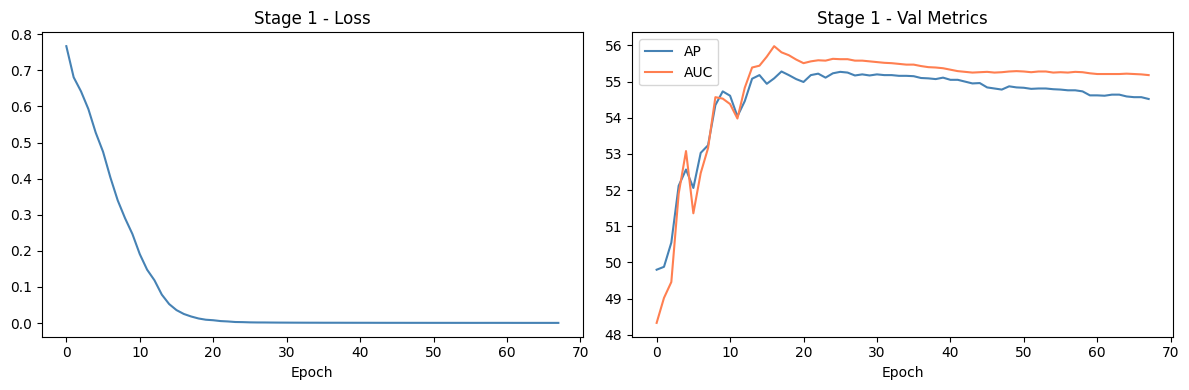

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s1_hist['loss'], color='steelblue')
axes[0].set_title('Stage 1 - Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(s1_hist['val_ap'],  label='AP',  color='steelblue')
axes[1].plot(s1_hist['val_auc'], label='AUC', color='coral')
axes[1].set_title('Stage 1 - Val Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); plt.tight_layout(); plt.show()


## Step 7 — Stage 2: Train Feature Pipeline

In [15]:
for p in (list(model.else_encoder.parameters()) +
          list(model.struct_encoder.parameters())):
    p.requires_grad_(False)

opt_feat   = optim.Adam(model.feat_encoder.parameters(), lr=LR, weight_decay=WD)
sched_feat = optim.lr_scheduler.StepLR(opt_feat, step_size=3, gamma=0.1)

loader_s2 = DataLoader(
    TensorDataset(
        TRIPLET_ANC.to(DEVICE),
        TRIPLET_POS.to(DEVICE),
        TRIPLET_NEG.to(DEVICE)),
    batch_size=16, shuffle=True)

s2_hist = {'loss': []}
print('=== Stage 2: Feature Pipeline ===')
for epoch in range(1, 201):
    model.train()
    ep_loss = 0.0
    for anc_ids, pos_ids, neg_ids in loader_s2:
        opt_feat.zero_grad()
        h_i = model.feat_encoder(node_features_d[anc_ids])
        h_j = model.feat_encoder(node_features_d[pos_ids])
        h_k = model.feat_encoder(node_features_d[neg_ids])
        loss = model.feat_encoder.contrastive_loss(h_i, h_j, h_k)
        loss.backward()
        opt_feat.step()
        ep_loss += loss.item()
    sched_feat.step()
    avg_loss = ep_loss / len(loader_s2)
    s2_hist['loss'].append(avg_loss)
    if epoch % 20 == 0:
        print(f'Ep {epoch:4d} | Contrastive Loss = {avg_loss:.4f}')
print('Stage 2 done')


=== Stage 2: Feature Pipeline ===
Ep   20 | Contrastive Loss = -1.1987
Ep   40 | Contrastive Loss = -1.2011
Ep   60 | Contrastive Loss = -1.2014
Ep   80 | Contrastive Loss = -1.1993
Ep  100 | Contrastive Loss = -1.2016
Ep  120 | Contrastive Loss = -1.2000
Ep  140 | Contrastive Loss = -1.2012
Ep  160 | Contrastive Loss = -1.1998
Ep  180 | Contrastive Loss = -1.2009
Ep  200 | Contrastive Loss = -1.2010
Stage 2 done


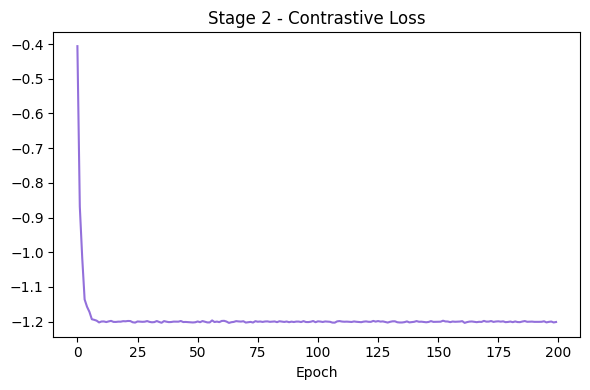

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(s2_hist['loss'], color='mediumpurple')
plt.title('Stage 2 - Contrastive Loss')
plt.xlabel('Epoch'); plt.tight_layout(); plt.show()


## Step 8 — Stage 3: Train Dynamic Gate Fusion

In [17]:
for p in model.feat_encoder.parameters():
    p.requires_grad_(False)

opt_gate = optim.Adam(
    list(model.graph_emb.parameters()) +
    list(model.gate_fusion.parameters()) +
    list(model.final_readout.parameters()),
    lr=LR, weight_decay=WD)

model.eval()
with torch.no_grad():
    X_B  = model.else_encoder(node_ids_d)
    h1_f = F.relu(model.struct_encoder.conv1(X_B, train_edge_d))
    H_S  = model.struct_encoder.conv2(h1_f, train_edge_d)
    H_F  = model.feat_encoder(node_features_d)
    X_G  = model.graph_emb(X_B)
print(f'H_S:{H_S.shape}  H_F:{H_F.shape}  X_G:{X_G.shape}')

s3_src = torch.cat([TRAIN_POS_SRC, TRAIN_NEG_SRC]).to(DEVICE)
s3_dst = torch.cat([TRAIN_POS_DST, TRAIN_NEG_DST]).to(DEVICE)
s3_lbl = torch.cat([torch.ones(len(TRAIN_POS_SRC)),
                    torch.zeros(len(TRAIN_NEG_SRC))]).to(DEVICE)
loader_s3 = DataLoader(
    TensorDataset(s3_src, s3_dst, s3_lbl),
    batch_size=BATCH_SIZE, shuffle=True)

s3_hist = {'loss': [], 'val_ap': [], 'val_auc': []}
best_ap, no_improve = 0.0, 0
print('=== Stage 3: Gate Fusion ===')
for epoch in range(1, 501):
    model.train()
    ep_loss = 0.0
    for b_src, b_dst, b_lbl in loader_s3:
        opt_gate.zero_grad()
        h_g  = model.gate_fusion(X_G, H_S, H_F)
        loss = DynamicGateFusion.gate_loss(
            h_g[b_src], h_g[b_dst], b_lbl, model.final_readout)
        loss.backward()
        opt_gate.step()
        ep_loss += loss.item()
    avg_loss = ep_loss / len(loader_s3)
    m = evaluate(model, NODE_IDS, TRAIN_EDGE_INDEX, NODE_FEATURES,
                 VAL_POS_SRC, VAL_POS_DST,
                 VAL_NEG_SRC, VAL_NEG_DST, DEVICE)
    s3_hist['loss'].append(avg_loss)
    s3_hist['val_ap'].append(m['ap'])
    s3_hist['val_auc'].append(m['auc'])
    if m['ap'] > best_ap:
        best_ap, no_improve = m['ap'], 0
        torch.save(model.state_dict(), '/tmp/best_fusion.pt')
    else:
        no_improve += 1
    if epoch % 20 == 0:
        print(f'Ep {epoch:4d} | Loss={avg_loss:.4f} | '
              f'AP={m["ap"]:.2f}% | AUC={m["auc"]:.2f}%')
    if no_improve >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break
model.load_state_dict(torch.load('/tmp/best_fusion.pt'))
print(f'Stage 3 done. Best Val AP = {best_ap:.2f}%')


H_S:torch.Size([2708, 128])  H_F:torch.Size([2708, 128])  X_G:torch.Size([2708, 128])
=== Stage 3: Gate Fusion ===
Ep   20 | Loss=0.2500 | AP=64.15% | AUC=64.30%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ep   40 | Loss=0.1246 | AP=65.38% | AUC=65.24%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Ep   60 | Loss=0.0640 | AP=65.29% | AUC=65.09%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Ep   80 | Loss=0.0298 | AP=65.62% | AUC=65.21%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Early stop at epoch 84
Stage 3 done. Best Val AP = 65.96%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


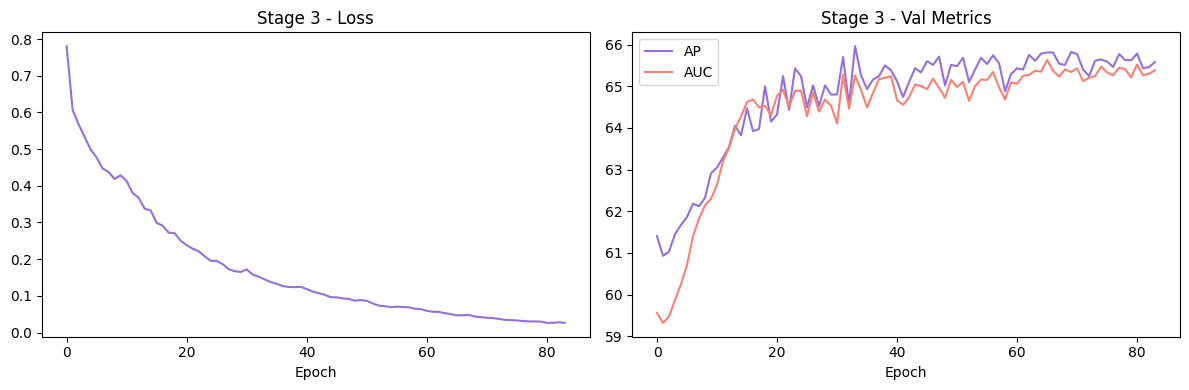

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s3_hist['loss'], color='mediumpurple')
axes[0].set_title('Stage 3 - Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(s3_hist['val_ap'],  label='AP',  color='mediumpurple')
axes[1].plot(s3_hist['val_auc'], label='AUC', color='salmon')
axes[1].set_title('Stage 3 - Val Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); plt.tight_layout(); plt.show()


## Step 9 — Evaluate on Test Set

In [19]:
for p in model.parameters():
    p.requires_grad_(True)

test_m = evaluate(
    model, NODE_IDS, TRAIN_EDGE_INDEX, NODE_FEATURES,
    TEST_POS_SRC, TEST_POS_DST,
    TEST_NEG_SRC, TEST_NEG_DST, DEVICE)

print('=' * 38)
print(f'  Dataset  : {DATASET_NAME}')
print(f'  Test AP  : {test_m["ap"]:.2f}%')
print(f'  Test AUC : {test_m["auc"]:.2f}%')
print('=' * 38)


  Dataset  : Cora
  Test AP  : 64.02%
  Test AUC : 64.65%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
